In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv('../Data/Telco_Cusomer_Churn.csv')

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors= 'coerce')
df.drop(columns=['customerID'], inplace=True)
df['TotalCharges'].fillna(0, inplace=True)
X = df.iloc[:,:-1]
y = df.iloc[:,-1]


C:\Users\USER\AppData\Local\Temp\ipykernel_47480\3895683071.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [11]:
from sklearn.model_selection import train_test_split
X_numerico = pd.get_dummies(X, drop_first=True)
y_num = y.map({'No': 0, 'Yes': 1}) 
X_train, X_test, y_train, y_test = train_test_split(X_numerico,y_num, test_size=0.2,random_state=42)

In [ ]:
ratio_balanceo = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

modelo_xgb_base = xgb.XGBClassifier(scale_pos_weight=ratio_balanceo, random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],             
    'learning_rate': [0.01, 0.05, 0.1]  
}

grid_search_xgb = GridSearchCV(
    estimator=modelo_xgb_base, 
    param_grid=param_grid_xgb, 
    cv=5, 
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print("Mejores parámetros para XGBoost:", grid_search_xgb.best_params_)

Mejores parámetros para XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}


In [13]:
param_grid_xgb_ampliado = {
    'n_estimators': [300, 400, 500],
    'max_depth': [7, 9, 11],             
    'learning_rate': [0.1, 0.2]  
}

grid_search_xgb_ampliado = GridSearchCV(
    estimator=modelo_xgb_base, 
    param_grid=param_grid_xgb_ampliado, 
    cv=5, 
    n_jobs=-1
)
grid_search_xgb_ampliado.fit(X_train, y_train)

print("Nuevos mejores parámetros XGBoost:", grid_search_xgb_ampliado.best_params_)


Nuevos mejores parámetros XGBoost: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300}


In [14]:
modelo_xgb_1 = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=7, 
    learning_rate=0.1, 
    scale_pos_weight=ratio_balanceo, 
    random_state=42
)
modelo_xgb_1.fit(X_train, y_train)

modelo_xgb_2 = grid_search_xgb_ampliado.best_estimator_


print("\n" + "="*50)
print("COMPETENCIA DE OVERFITTING: MODELO 1 VS MODELO 2")
print("="*50)

print("\n--- MODELO 1 (Max Depth 7 | Est 300) ---")
print("Train (Estudio):")
print(classification_report(y_train, modelo_xgb_1.predict(X_train)))
print("Test (Examen Real):")
print(classification_report(y_test, modelo_xgb_1.predict(X_test)))

print("\n" + "-"*50)

print("\n--- MODELO 2 (Parámetros Ampliados) ---")
print("Train (Estudio):")
print(classification_report(y_train, modelo_xgb_2.predict(X_train)))
print("Test (Examen Real):")
print(classification_report(y_test, modelo_xgb_2.predict(X_test)))


COMPETENCIA DE OVERFITTING: MODELO 1 VS MODELO 2

--- MODELO 1 (Max Depth 7 | Est 300) ---
Train (Estudio):
              precision    recall  f1-score   support

           0       1.00      0.93      0.97      4138
           1       0.85      1.00      0.92      1496

    accuracy                           0.95      5634
   macro avg       0.92      0.97      0.94      5634
weighted avg       0.96      0.95      0.95      5634

Test (Examen Real):
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1036
           1       0.56      0.67      0.61       373

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409


--------------------------------------------------

--- MODELO 2 (Parámetros Ampliados) ---
Train (Estudio):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      413

In [15]:

modelo_xgb_tamed = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=6,            
    learning_rate=0.05,     
    scale_pos_weight=ratio_balanceo, 
    random_state=42
)

param_grid_reg = {
    'gamma': [0.5, 1, 5],               
    'subsample': [0.7, 0.8],            
    'colsample_bytree': [0.7, 0.8],     
    'reg_lambda': [1, 5, 10]            
}

grid_search_reg = GridSearchCV(
    estimator=modelo_xgb_tamed,
    param_grid=param_grid_reg,
    cv=3, 
    n_jobs=-1,
    scoring='f1'
)

grid_search_reg.fit(X_train, y_train)

print("Mejores parámetros encontrados:", grid_search_reg.best_params_)
modelo_final = grid_search_reg.best_estimator_

print("\n--- TEST FINAL (XGBOOST REGULARIZADO) ---")
print(classification_report(y_test, modelo_final.predict(X_test)))

Mejores parámetros encontrados: {'colsample_bytree': 0.8, 'gamma': 5, 'reg_lambda': 10, 'subsample': 0.7}

--- TEST FINAL (XGBOOST REGULARIZADO) ---
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.79      0.74      1409
weighted avg       0.82      0.77      0.78      1409



In [16]:
print("=== CHEQUEO DE SALUD DEL MODELO (TRAIN VS TEST) ===")
print("\n--- RENDIMIENTO EN ENTRENAMIENTO ---")
print(classification_report(y_train, modelo_final.predict(X_train)))

print("\n--- RENDIMIENTO EN PRUEBA ---")
print(classification_report(y_test, modelo_final.predict(X_test)))

probabilidades_xgb = modelo_final.predict_proba(X_test)[:, 1]
umbral_nuevo = 0.70 
predicciones_finales = np.where(probabilidades_xgb >= umbral_nuevo, 1, 0)

print(f"\n" + "="*50)
print(f"RESULTADO FINAL CON UMBRAL DE {umbral_nuevo}")
print("="*50)
print(confusion_matrix(y_test, predicciones_finales))
print(classification_report(y_test, predicciones_finales))

=== CHEQUEO DE SALUD DEL MODELO (TRAIN VS TEST) ===

--- RENDIMIENTO EN ENTRENAMIENTO ---
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      4138
           1       0.55      0.84      0.66      1496

    accuracy                           0.77      5634
   macro avg       0.74      0.79      0.75      5634
weighted avg       0.83      0.77      0.79      5634


--- RENDIMIENTO EN PRUEBA ---
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.79      0.74      1409
weighted avg       0.82      0.77      0.78      1409


RESULTADO FINAL CON UMBRAL DE 0.7
[[921 115]
 [147 226]]
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1036
           1       0.66      0.61      0.63       373

   

In [24]:
df = pd.read_csv('../Data/Telco_Cusomer_Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop(columns=['customerID'], inplace=True)

df['Charges_Ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_Services'] = (df[servicios] == 'Yes').sum(axis=1)

df['Is_New_Customer'] = np.where(df['tenure'] <= 6, 1, 0)

X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
y = df['Churn'].map({'No': 0, 'Yes': 1}) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ratio_balanceo = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

modelo_final_ingenieria = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.05,
    gamma=5,
    reg_lambda=10,
    subsample=0.7,
    colsample_bytree=0.8,
    scale_pos_weight=ratio_balanceo,
    random_state=42
)

modelo_final_ingenieria.fit(X_train, y_train)

probabilidades = modelo_final_ingenieria.predict_proba(X_test)[:, 1]
umbral = 0.65 
predicciones = np.where(probabilidades >= umbral, 1, 0)

print(f"--- RESULTADO CON INGENIERÍA DE VARIABLES (Umbral {umbral}) ---")
print(confusion_matrix(y_test, predicciones))
print(classification_report(y_test, predicciones))

--- RESULTADO CON INGENIERÍA DE VARIABLES (Umbral 0.65) ---
[[888 148]
 [115 258]]
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1036
           1       0.64      0.69      0.66       373

    accuracy                           0.81      1409
   macro avg       0.76      0.77      0.77      1409
weighted avg       0.82      0.81      0.82      1409



C:\Users\USER\AppData\Local\Temp\ipykernel_47480\911184708.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(15), palette='magma')


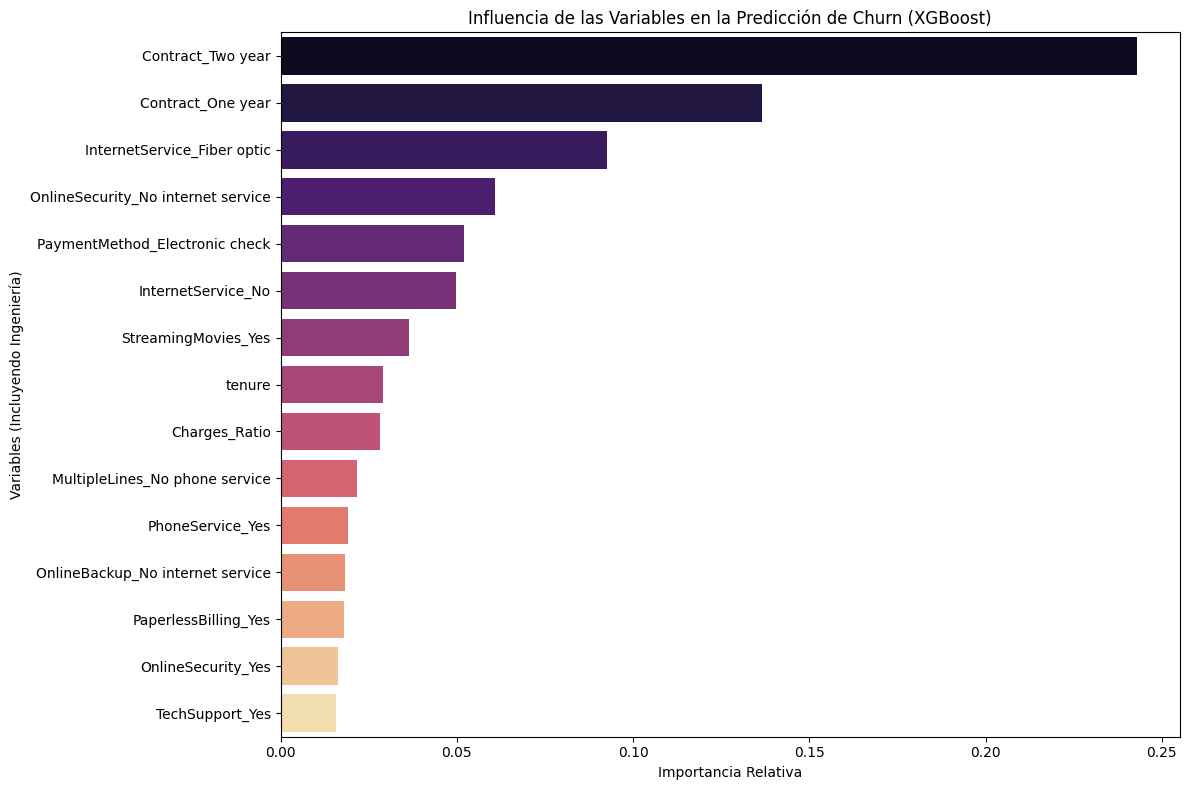

--- TOP 10 VARIABLES MÁS IMPORTANTES ---
                              Variable  Importancia
28                   Contract_Two year     0.243010
27                   Contract_One year     0.136548
13         InternetService_Fiber optic     0.092749
15  OnlineSecurity_No internet service     0.060968
31      PaymentMethod_Electronic check     0.052112
14                  InternetService_No     0.049892
26                 StreamingMovies_Yes     0.036432
1                               tenure     0.029165
4                        Charges_Ratio     0.028303
11      MultipleLines_No phone service     0.021748


In [ ]:
importancias = modelo_final_ingenieria.feature_importances_
nombres_columnas = X_train.columns

df_importancias = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(15), palette='magma')
plt.title('Influencia de las Variables en la Predicción de Churn (XGBoost)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables (Incluyendo Ingeniería)')
plt.tight_layout()
plt.show()

print("--- TOP 10 VARIABLES MÁS IMPORTANTES ---")
print(df_importancias.head(10))

In [26]:
top_10_cols = [
    'Contract_Two year', 'Contract_One year', 'InternetService_Fiber optic', 
    'OnlineSecurity_No internet service', 'PaymentMethod_Electronic check', 
    'InternetService_No', 'StreamingMovies_Yes', 'tenure', 
    'Charges_Ratio', 'MultipleLines_No phone service'
]

X = pd.get_dummies(df, drop_first=True)
X_top10 = X[top_10_cols]
y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(X_top10, y, test_size=0.2, random_state=42)

ratio_balanceo = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

modelo_top10 = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.05,
    gamma=5,
    reg_lambda=10,
    subsample=0.7,
    colsample_bytree=0.8,
    scale_pos_weight=ratio_balanceo,
    random_state=42
)

modelo_top10.fit(X_train, y_train)

probs = modelo_top10.predict_proba(X_test)[:, 1]
umbral = 0.65
predicciones = np.where(probs >= umbral, 1, 0)

print(f"--- RESULTADO XGBOOST (SOLO TOP 10 - Umbral {umbral}) ---")
print(confusion_matrix(y_test, predicciones))
print(classification_report(y_test, predicciones))

--- RESULTADO XGBOOST (SOLO TOP 10 - Umbral 0.65) ---
[[872 164]
 [106 267]]
              precision    recall  f1-score   support

           0       0.89      0.84      0.87      1036
           1       0.62      0.72      0.66       373

    accuracy                           0.81      1409
   macro avg       0.76      0.78      0.77      1409
weighted avg       0.82      0.81      0.81      1409



In [ ]:
orden_oficial = [
    'Contract_Two year', 'Contract_One year', 'InternetService_Fiber optic', 
    'OnlineSecurity_No internet service', 'PaymentMethod_Electronic check', 
    'InternetService_No', 'StreamingMovies_Yes', 'tenure', 
    'Charges_Ratio', 'MultipleLines_No phone service'
]

# 2. Definición de los 5 nuevos perfiles
nuevos_clientes = pd.DataFrame([
    # PERFIL 1: El "Caminante Blanco" (Riesgo Extremo)
    # Mes a mes, Fibra, paga con cheque, acaba de llegar.
    [0, 0, 1, 0, 1, 0, 0, 1, 0.95, 0], 
    
    # PERFIL 2: El "Abuelito Leal" (Riesgo Nulo)
    # Contrato 2 años, sin internet, 6 años de antigüedad, ratio bajísimo.
    [1, 0, 0, 1, 0, 1, 0, 72, 0.01, 0], 
    
    # PERFIL 3: El "Moderno Indeciso" (Riesgo Medio-Alto)
    # Contrato 1 año pero tiene Fibra y usa cheque electrónico. 10 meses.
    [0, 1, 1, 0, 1, 0, 1, 10, 0.12, 0], 
    
    # PERFIL 4: El "Cazador de Ofertas" (Riesgo Sorpresa)
    # Mes a mes, SIN internet (solo teléfono), 24 meses. Suele quedarse por inercia.
    [0, 0, 0, 0, 0, 0, 0, 24, 0.05, 1], 
    
    # PERFIL 5: El "Premium Atado" (Riesgo Bajo)
    # Tiene todo (Streaming, etc), pero con contrato de 2 años y mucha antigüedad.
    [1, 0, 1, 0, 0, 0, 1, 60, 0.02, 0]
], columns=orden_oficial)

probabilidades = modelo_top10.predict_proba(nuevos_clientes)[:, 1]

umbral = 0.65
predicciones = np.where(probabilidades >= umbral, '¡SE VA! (Churn)', 'Se queda (Leal)')

simulacion = pd.DataFrame({
    'ID_Cliente': ['Caminante Blanco', 'Abuelito Leal', 'Moderno Indeciso', 'Cazador Ofertas', 'Premium Atado'],
    'Probabilidad': [f"{p:.2%}" for p in probabilidades],
    'Veredicto': predicciones
})

print(simulacion)

         ID_Cliente Probabilidad        Veredicto
0  Caminante Blanco       88.27%  ¡SE VA! (Churn)
1     Abuelito Leal        2.55%  Se queda (Leal)
2  Moderno Indeciso       63.17%  Se queda (Leal)
3   Cazador Ofertas       41.03%  Se queda (Leal)
4     Premium Atado       21.81%  Se queda (Leal)


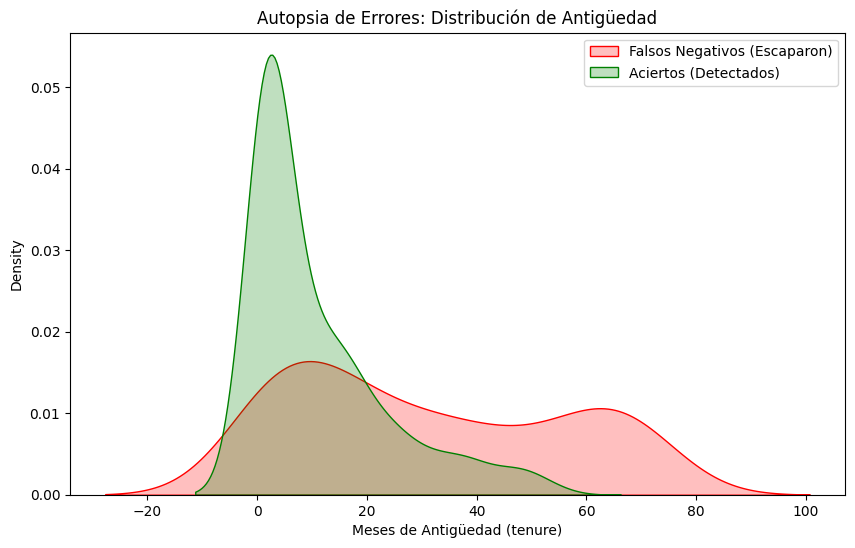

--- COMPARATIVA DE MEDIAS ---
                                    Escaparon (FN)  Detectados (VP)
Contract_Two year                         0.094340         0.000000
Contract_One year                         0.207547         0.003745
InternetService_Fiber optic               0.424528         0.827715
OnlineSecurity_No internet service        0.179245         0.003745
PaymentMethod_Electronic check            0.283019         0.719101
InternetService_No                        0.179245         0.003745
StreamingMovies_Yes                       0.358491         0.441948
tenure                                   30.952830        10.677903
Charges_Ratio                             0.169986         0.393694
MultipleLines_No phone service            0.075472         0.082397
Real                                      1.000000         1.000000
Prediccion                                0.000000         1.000000


In [ ]:
probs_test = modelo_top10.predict_proba(X_test)[:, 1]
predicciones_test = np.where(probs_test >= 0.65, 1, 0)

analisis_errores = X_test.copy()
analisis_errores['Real'] = y_test.values # Usamos .values para evitar líos de índices
analisis_errores['Prediccion'] = predicciones_test

falsos_negativos = analisis_errores[(analisis_errores['Real'] == 1) & (analisis_errores['Prediccion'] == 0)]

aciertos_churn = analisis_errores[(analisis_errores['Real'] == 1) & (analisis_errores['Prediccion'] == 1)]

plt.figure(figsize=(10, 6))
sns.kdeplot(falsos_negativos['tenure'], label='Falsos Negativos (Escaparon)', fill=True, color="red")
sns.kdeplot(aciertos_churn['tenure'], label='Aciertos (Detectados)', fill=True, color="green")
plt.title('Autopsia de Errores: Distribución de Antigüedad')
plt.xlabel('Meses de Antigüedad (tenure)')
plt.legend()
plt.show()

print("--- COMPARATIVA DE MEDIAS ---")
comparativa = pd.DataFrame({
    'Escaparon (FN)': falsos_negativos.mean(),
    'Detectados (VP)': aciertos_churn.mean()
})
print(comparativa)

In [33]:
import joblib

joblib.dump(modelo_top10, 'modelo_xgboost_top10.pkl')
joblib.dump(top_10_cols, 'columnas_top10.pkl')

['columnas_top10.pkl']

## Se continua en SVM para vver si rinde mejor!
